### Установка и импорт библиотек

In [ ]:
!pip install -q torch torchvision scikit-learn seaborn

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b2, EfficientNet_B2_Weights

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

### Параметры и устройство

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

dataset_path = "/content/drive/MyDrive/ML/Data"
batch_size = 32
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

Device: cpu


### Предобработка


In [ ]:
weights = EfficientNet_B2_Weights.IMAGENET1K_V1

train_transforms = transforms.Compose([
    transforms.Resize((320, 320)),
    transforms.RandomResizedCrop(288),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean,
                         std=weights.transforms().std)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((288, 288)),
    transforms.CenterCrop(288),
    transforms.ToTensor(),
    transforms.Normalize(mean=weights.transforms().mean,
                         std=weights.transforms().std)
])

### Загрузка датасета и разбиение на train / val / test

In [ ]:
full_dataset = datasets.ImageFolder(root=dataset_path)
class_names = full_dataset.classes
num_classes = len(class_names)

print("Классы:", class_names)
print("Количество изображений:", len(full_dataset))

Классы: ['anime', 'cartoon', 'human']
Количество изображений: 8917


In [ ]:
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(seed)
)

In [ ]:
train_dataset.dataset = copy.deepcopy(full_dataset)
val_dataset.dataset = copy.deepcopy(full_dataset)
test_dataset.dataset = copy.deepcopy(full_dataset)

train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_test_transforms
test_dataset.dataset.transform = val_test_transforms

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

Train: 6241
Val:   1337
Test:  1339


### Функция создания модели EfficientNet-B2


In [ ]:
def create_efficientnet_b2_model(num_classes=3, freeze_features=True):
    model = efficientnet_b2(weights=EfficientNet_B2_Weights.IMAGENET1K_V1)

    if freeze_features:
        for param in model.parameters():
            param.requires_grad = False
    else:
        for param in model.parameters():
            param.requires_grad = True

    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)

    # Новый классификатор обучается всегда
    for param in model.classifier.parameters():
        param.requires_grad = True

    return model.to(device)

### Функции обучения и оценки

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10, lr=1e-4):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": []
    }

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")

        # ---- train ----
        model.train()
        running_loss = 0.0
        running_corrects = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = running_corrects.double().item() / total

        # ---- val ----
        model.eval()
        running_loss = 0.0
        running_corrects = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = running_corrects.double().item() / total

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
        print("-" * 50)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_model_wts)
    return model, history

In [ ]:
def evaluate_model(model, data_loader, class_names):
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            y_true.extend(labels.numpy())
            y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=class_names)

    return {
        "accuracy": acc,
        "recall_macro": recall,
        "f1_macro": f1,
        "cm": cm,
        "y_true": y_true,
        "y_pred": y_pred,
        "report": report
    }

### Визуализация графиков обучения

In [ ]:
def plot_history(history, title="Training history"):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train loss")
    plt.plot(epochs, history["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train accuracy")
    plt.plot(epochs, history["val_acc"], label="Val accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

### Матрица ошибок

In [ ]:
def plot_confusion_matrix(cm, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Истинный класс")
    plt.title(title)
    plt.show()

### Обучение EfficientNet-B2 с замороженными слоями

In [ ]:
efficientnet_frozen = create_efficientnet_b2_model(
    num_classes=num_classes,
    freeze_features=True
)

efficientnet_frozen, frozen_history = train_model(
    efficientnet_frozen,
    train_loader,
    val_loader,
    epochs=10,
    lr=1e-4
)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 111MB/s]


Epoch 1/10
Train Loss: 0.7978 | Train Acc: 0.7957
Val   Loss: 0.6898 | Val   Acc: 0.8467
--------------------------------------------------
Epoch 2/10
Train Loss: 0.4515 | Train Acc: 0.9486
Val   Loss: 0.4886 | Val   Acc: 0.9147
--------------------------------------------------
Epoch 3/10
Train Loss: 0.3125 | Train Acc: 0.9587
Val   Loss: 0.3400 | Val   Acc: 0.9634
--------------------------------------------------
Epoch 4/10
Train Loss: 0.2496 | Train Acc: 0.9561
Val   Loss: 0.2727 | Val   Acc: 0.9738
--------------------------------------------------
Epoch 5/10
Train Loss: 0.2072 | Train Acc: 0.9638
Val   Loss: 0.2575 | Val   Acc: 0.9626
--------------------------------------------------
Epoch 6/10
Train Loss: 0.1833 | Train Acc: 0.9689
Val   Loss: 0.2266 | Val   Acc: 0.9776
--------------------------------------------------
Epoch 7/10
Train Loss: 0.1631 | Train Acc: 0.9683
Val   Loss: 0.1739 | Val   Acc: 0.9828
--------------------------------------------------
Epoch 8/10
Train Los

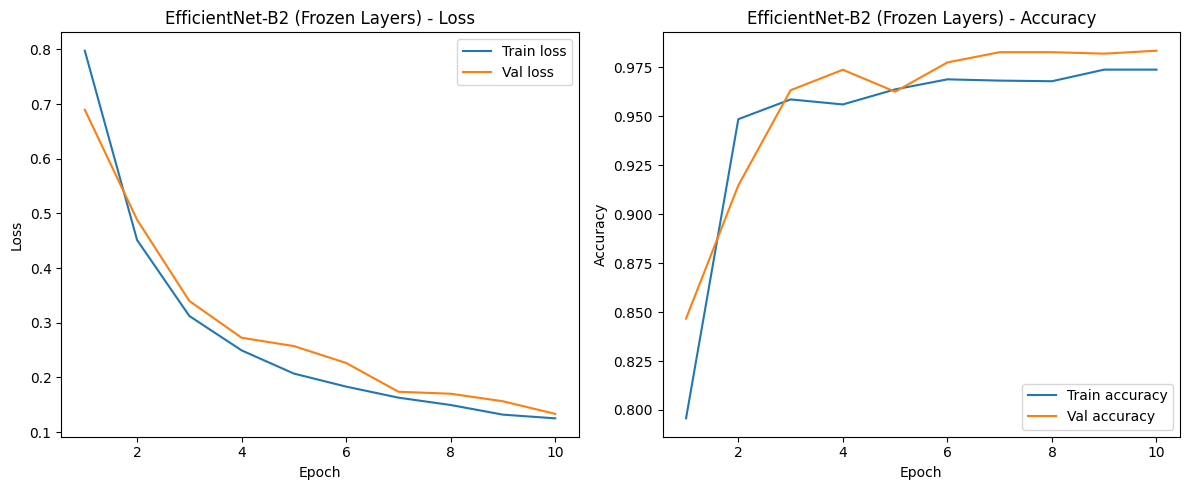

In [ ]:
plot_history(frozen_history, title="EfficientNet-B2 (Frozen Layers)")

In [ ]:
frozen_metrics = evaluate_model(efficientnet_frozen, test_loader, class_names)

print("=== EfficientNet-B2 with frozen layers ===")
print(f"Accuracy: {frozen_metrics['accuracy']:.4f}")
print(f"Recall_macro: {frozen_metrics['recall_macro']:.4f}")
print(f"F1_macro: {frozen_metrics['f1_macro']:.4f}")
print("\nClassification report:\n")
print(frozen_metrics["report"])

=== EfficientNet-B2 with frozen layers ===
Accuracy: 0.9739
Recall_macro: 0.9739
F1_macro: 0.9741

Classification report:

              precision    recall  f1-score   support

       anime       1.00      0.95      0.97       448
     cartoon       0.93      1.00      0.96       447
       human       1.00      0.98      0.99       444

    accuracy                           0.97      1339
   macro avg       0.98      0.97      0.97      1339
weighted avg       0.98      0.97      0.97      1339



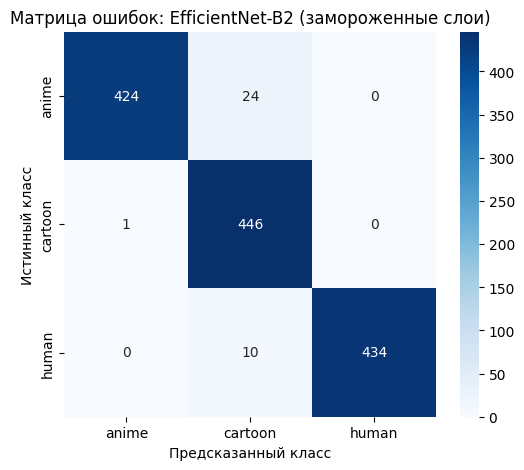

In [ ]:
plot_confusion_matrix(
    frozen_metrics["cm"],
    class_names,
    title="Матрица ошибок: EfficientNet-B2 (замороженные слои)"
)

### Обучение EfficientNet-B2 с размороженными слоями

In [ ]:
efficientnet_unfrozen = create_efficientnet_b2_model(
    num_classes=num_classes,
    freeze_features=False
)

efficientnet_unfrozen, unfrozen_history = train_model(
    efficientnet_unfrozen,
    train_loader,
    val_loader,
    epochs=5,
    lr=1e-5
)

Downloading: "https://download.pytorch.org/models/efficientnet_b2_rwightman-c35c1473.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b2_rwightman-c35c1473.pth


100%|██████████| 35.2M/35.2M [00:00<00:00, 102MB/s]


Epoch 1/5
Train Loss: 0.7345 | Train Acc: 0.8201
Val   Loss: 0.4758 | Val   Acc: 0.9132
--------------------------------------------------
Epoch 2/5


In [ ]:
plot_history(unfrozen_history, title="EfficientNet-B2 (Unfrozen Layers)")

In [ ]:
unfrozen_metrics = evaluate_model(efficientnet_unfrozen, test_loader, class_names)

print("=== EfficientNet-B2 with unfrozen layers ===")
print(f"Accuracy: {unfrozen_metrics['accuracy']:.4f}")
print(f"Recall_macro: {unfrozen_metrics['recall_macro']:.4f}")
print(f"F1_macro: {unfrozen_metrics['f1_macro']:.4f}")
print("\nClassification report:\n")
print(unfrozen_metrics["report"])

In [ ]:
plot_confusion_matrix(
    unfrozen_metrics["cm"],
    class_names,
    title="Матрица ошибок: EfficientNet-B2 (размороженные слои)"
)

### Сравнение двух методов

In [ ]:
comparison = {
    "Frozen": {
        "Accuracy": frozen_metrics["accuracy"],
        "Recall_macro": frozen_metrics["recall_macro"],
        "F1_macro": frozen_metrics["f1_macro"]
    },
    "Unfrozen": {
        "Accuracy": unfrozen_metrics["accuracy"],
        "Recall_macro": unfrozen_metrics["recall_macro"],
        "F1_macro": unfrozen_metrics["f1_macro"]
    }
}

print(comparison)

In [ ]:
methods = ["Frozen", "Unfrozen"]
acc_values = [comparison[m]["Accuracy"] for m in methods]
recall_values = [comparison[m]["Recall_macro"] for m in methods]
f1_values = [comparison[m]["F1_macro"] for m in methods]

x = np.arange(len(methods))
width = 0.25

plt.figure(figsize=(9, 5))
plt.bar(x - width, acc_values, width, label="Accuracy")
plt.bar(x, recall_values, width, label="Recall_macro")
plt.bar(x + width, f1_values, width, label="F1_macro")

plt.xticks(x, methods)
plt.ylim(0, 1)
plt.ylabel("Metric value")
plt.title("Сравнение EfficientNet-B2: замороженные vs размороженные слои")
plt.legend()
plt.show()

### Полный вывод в таблицу

In [ ]:
results_df = pd.DataFrame({
    "Метод": ["Замороженные слои", "Размороженные слои"],
    "Accuracy": [frozen_metrics["accuracy"], unfrozen_metrics["accuracy"]],
    "Recall_macro": [frozen_metrics["recall_macro"], unfrozen_metrics["recall_macro"]],
    "F1_macro": [frozen_metrics["f1_macro"], unfrozen_metrics["f1_macro"]],
})

results_df